# **A CNN-Based Deep Learning Framework for Parkinson’s Disease Classification**

## **Dataset Downloading**

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/parkinsons-drawings

Dataset URL: https://www.kaggle.com/datasets/kmader/parkinsons-drawings
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 41.4M/41.4M [00:00<00:00, 118MB/s]



In [ ]:
!unzip -q parkinsons-drawings.zip

## **Imports**

In [ ]:
import os
import shutil
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

#### **Dataset Organization**

In [ ]:
base_dir = "drawings"
shutil.rmtree(base_dir)

In [ ]:
os.makedirs("dataset", exist_ok=True)

In [ ]:
dataset_base_dir = "dataset"
classes = ["healthy", "parkinson"]

for category in ["training", "testing"]:
    for class_name in classes:
        # Create destination directory
        dest_dir = os.path.join(dataset_base_dir, category, class_name)
        os.makedirs(dest_dir, exist_ok=True)

        # Define source directories and move files
        for source_base in ["spiral", "wave"]:
            source_dir = os.path.join(source_base, category, class_name)
            if os.path.exists(source_dir):
                for file_name in os.listdir(source_dir):
                    shutil.move(os.path.join(source_dir, file_name), dest_dir)
            else:
                print(f"Warning: Source directory not found: {source_dir}")

print("Dataset organization complete.")

# Clean up the original spiral and wave directories if they are empty
for source_base in ["spiral", "wave"]:
    if os.path.exists(source_base):
        try:
            shutil.rmtree(source_base)
            print(f"Cleaned up empty directory: {source_base}")
        except OSError as e:
            print(f"Error removing directory {source_base}: {e}")

Dataset organization complete.
Cleaned up empty directory: spiral
Cleaned up empty directory: wave


**Train Dataset**

In [ ]:
train_dir = "dataset/training"

list_of_directories = os.listdir(train_dir)
counts = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    counts.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

healthy has 72 images
parkinson has 72 images


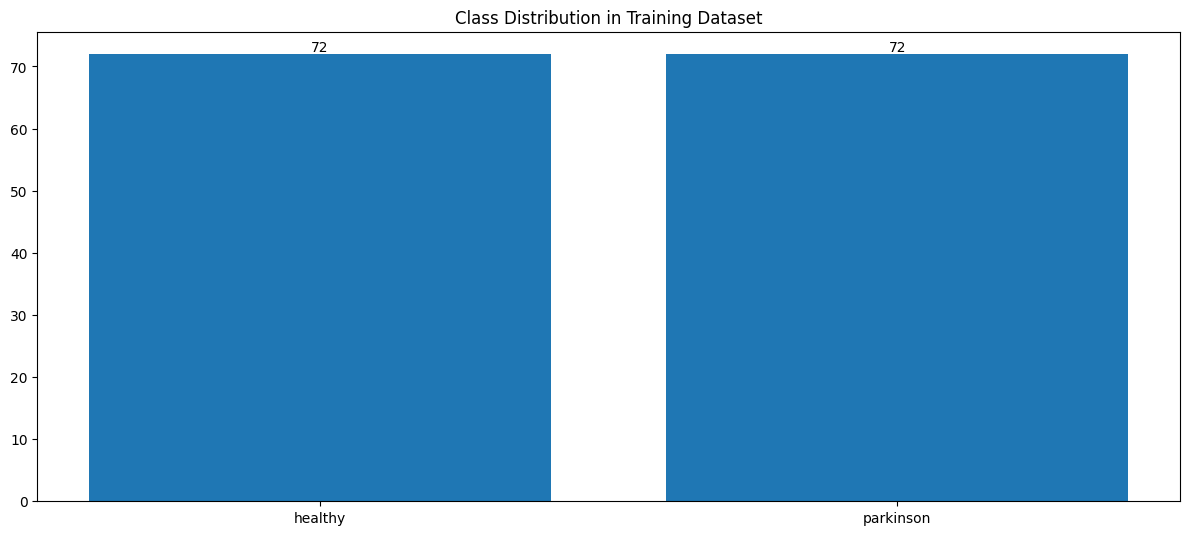

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories, counts)

plt.xticks(rotation=90)
plt.title("Class Distribution in Training Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

**Test Dataset**

In [ ]:
test_dir = "dataset/testing"

list_of_directories_test = os.listdir(test_dir)
test_count_images = []

for dir in list_of_directories_test:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    test_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

healthy has 30 images
parkinson has 30 images


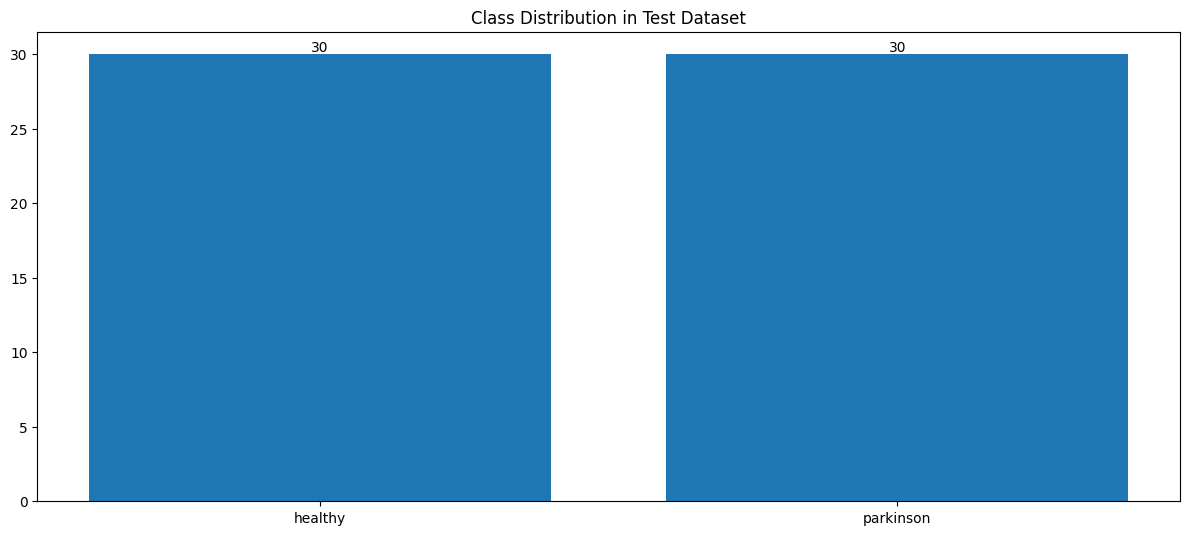

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_test, test_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Test Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

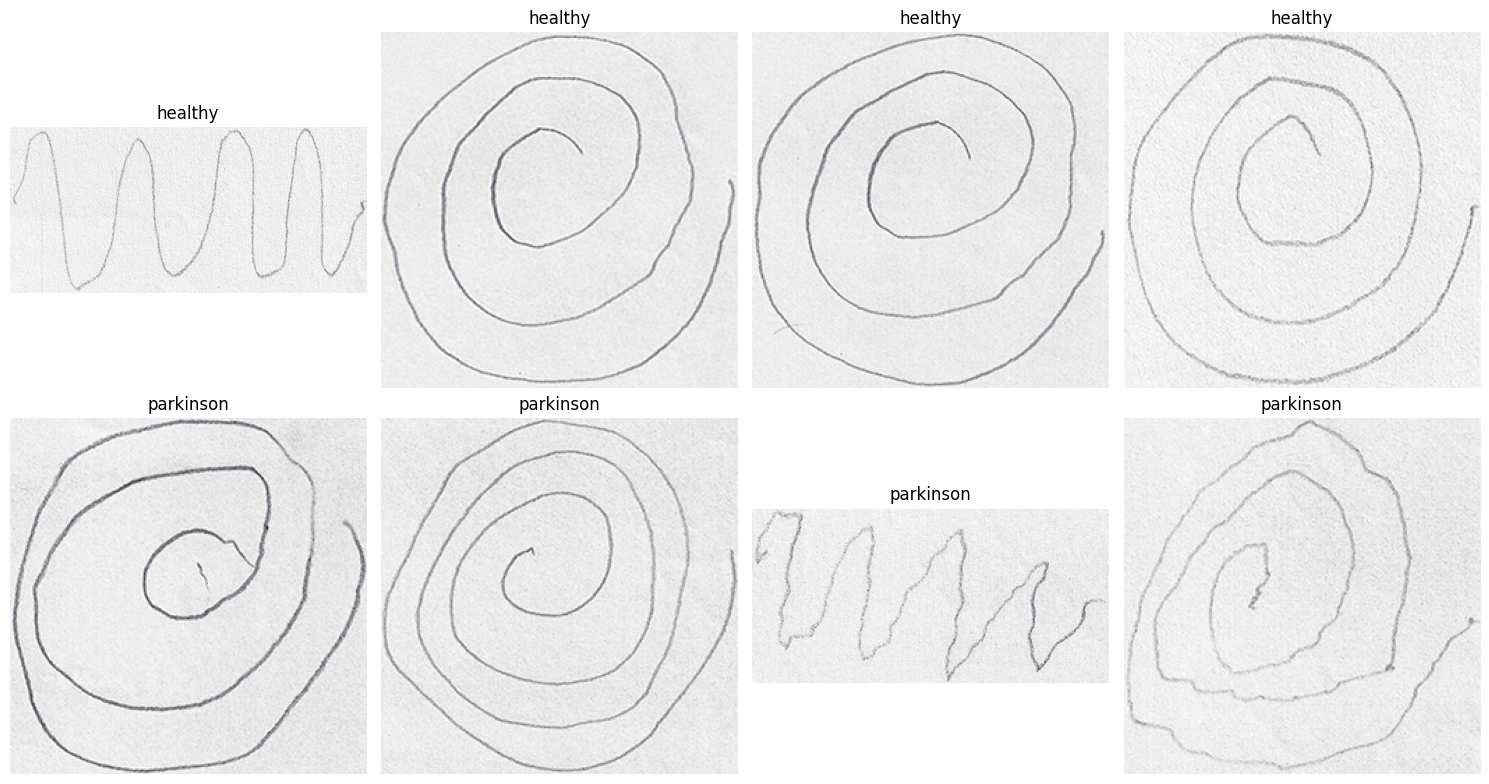

In [ ]:
# Display 4 images from each class

def sample_images_display(folder_path, num_images=4):
    # class folders
    classes = sorted([d for d in os.listdir(folder_path)
                     if os.path.isdir(os.path.join(folder_path, d))])

    # Setting up the plot
    fig, axes = plt.subplots(len(classes), num_images, figsize=(15, 4 * len(classes)))

    sns.set_style("whitegrid")

    for i, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)

        # fetching images
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Random selection of images from classes
        selected_images = random.sample(image_files, min(num_images, len(image_files)))

        for j, img_file in enumerate(selected_images):
            img_path = os.path.join(class_path, img_file)

            # Load and display image
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{class_name}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

    return classes

# calling
folder_path = 'dataset/training'
classes = sample_images_display(folder_path, num_images=4)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

healthy_images_path = "dataset/training/healthy"
parkinson_images_path = "dataset/training/parkinson"

generating_data = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.08,
    height_shift_range = 0.08,
    zoom_range = 0.1,
    brightness_range = [0.8, 1.2],
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest'
)

In [ ]:
def augement_the_data(input_folder, output_folder, num_augement_to_gen=2):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for image_name in os.listdir(input_folder):
        img = load_img(os.path.join(input_folder, image_name))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        i = 0
        for b in generating_data.flow(x, batch_size=1, save_to_dir = output_folder,
                                      save_prefix = image_name.split(".")[0], save_format='png'):
            i += 1
            if i >= num_augement_to_gen:
                break

In [ ]:
augement_the_data(healthy_images_path, "dataset/train/healthy", num_augement_to_gen=3)

In [ ]:
augement_the_data(parkinson_images_path, "dataset/train/parkinson", num_augement_to_gen=3)

In [ ]:
shutil.rmtree("dataset/training")

In [ ]:
# After Augmentation
train_dir = "dataset/train"

list_of_directories = os.listdir(train_dir)
counts = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    counts.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

healthy has 216 images
parkinson has 216 images


**Sample data visualization**

In [ ]:
base_dir = "dataset"

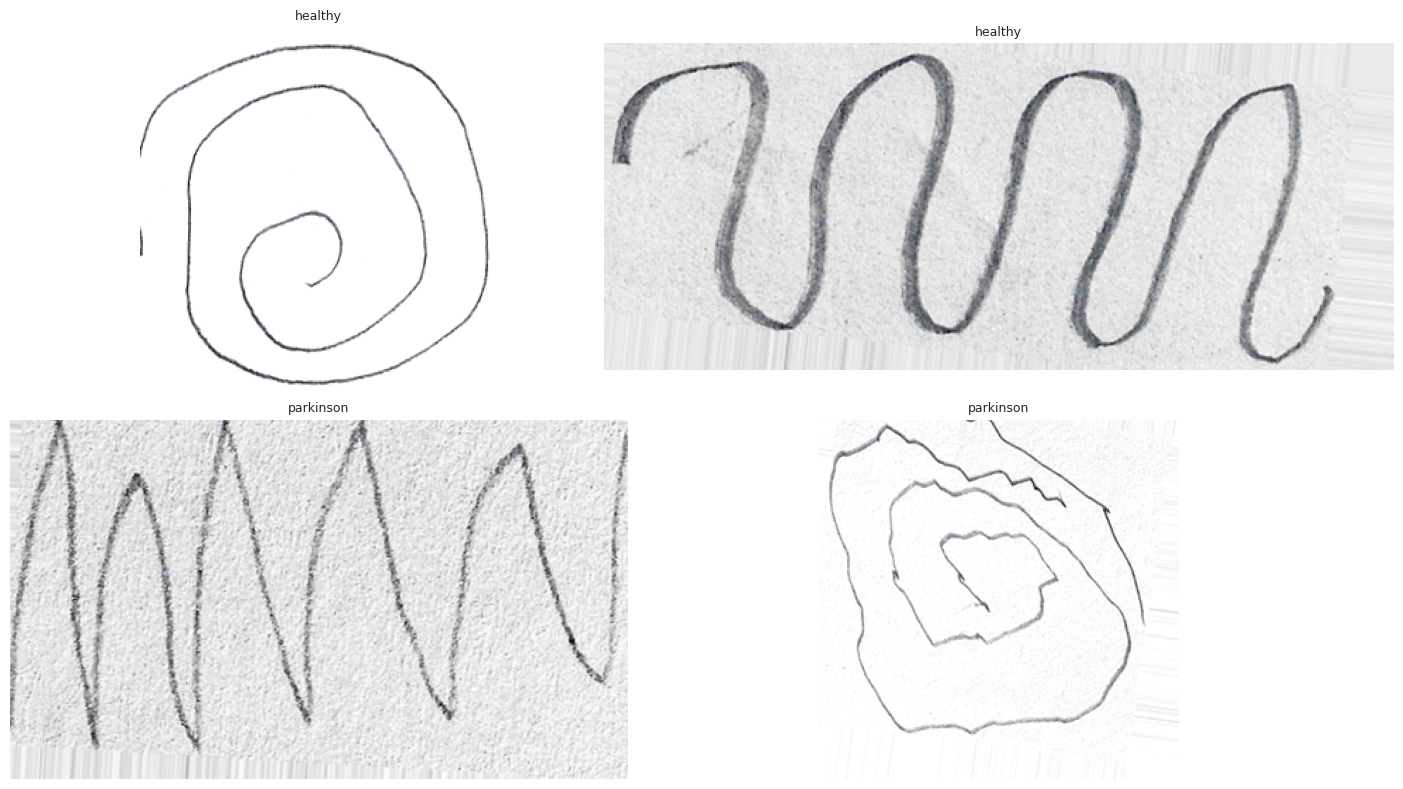

In [ ]:
classes = os.listdir(os.path.join(base_dir, "train"))

images_per_class = 2
total_images = len(classes) * images_per_class

cols = 2
rows = 2

plt.figure(figsize=(15, 4 * rows))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(os.path.join(base_dir, "train"), class_name)

    images = random.sample(os.listdir(class_path), images_per_class)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_index)
        plt.imshow(img, cmap='gray')
        plt.title(class_name, fontsize=9)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = "dataset/train"
test_dir = "dataset/testing"

In [ ]:
img_size = (224, 224)
batch_size = 16

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% of training data for validation
)

# Only rescaling for validation and testing, no additional augmentations
val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training' # Specify training subset
)

val_generator = train_datagen.flow_from_directory( # Use train_datagen for validation split
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation' # Specify validation subset
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 346 images belonging to 2 classes.
Found 86 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


## **Class Imbalance Check**

In [ ]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'healthy': 0, 'parkinson': 1}

Imbalance Ratio: 1.00


## **Model Building**

In [ ]:
def evaluate_model(model, name, generator):
    print(f"\nEvaluating {name}...")
    results = model.evaluate(generator, verbose=0)
    metrics = {
        'Model': name,
        'Loss': results[0],
        'Accuracy': results[1],
        'Precision': results[2],
        'Recall': results[3],
        'F1-Score': results[4]
    }
    return metrics

In [ ]:
class_len = train_generator.num_classes
epochs = 30

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.applications import VGG19, MobileNetV2, ResNet101, DenseNet201

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

#### **CNN Model**

In [ ]:
cnn_model = Sequential([
    Input(shape=(img_size[0], img_size[1], 3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [ ]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [ ]:
cnn_history = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, callbacks=callbacks)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5520 - f1_score: 0.5517 - loss: 1.1031 - precision: 0.5520 - recall: 0.5520 - val_accuracy: 0.5000 - val_f1_score: 0.3333 - val_loss: 0.7461 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.5116 - f1_score: 0.5116 - loss: 1.2495 - precision: 0.5116 - recall: 0.5116 - val_accuracy: 0.5000 - val_f1_score: 0.3333 - val_loss: 1.1443 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.5087 - f1_score: 0.5084 - loss: 1.1735 - precision: 0.5087 - recall: 0.5087 - val_accuracy: 0.5000 - val_f1_score: 0.3333 - val_loss: 1.8253 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 348ms/step - accuracy: 0.5809 - f1_score: 0.5808 - loss: 1.0268 - precision: 0.5809 - recall: 0.5809 - val_accuracy: 0.5000 - val_f1_score: 0.3333 - val_loss: 2.6499 - val_precision: 0.5000 - val_recall: 0

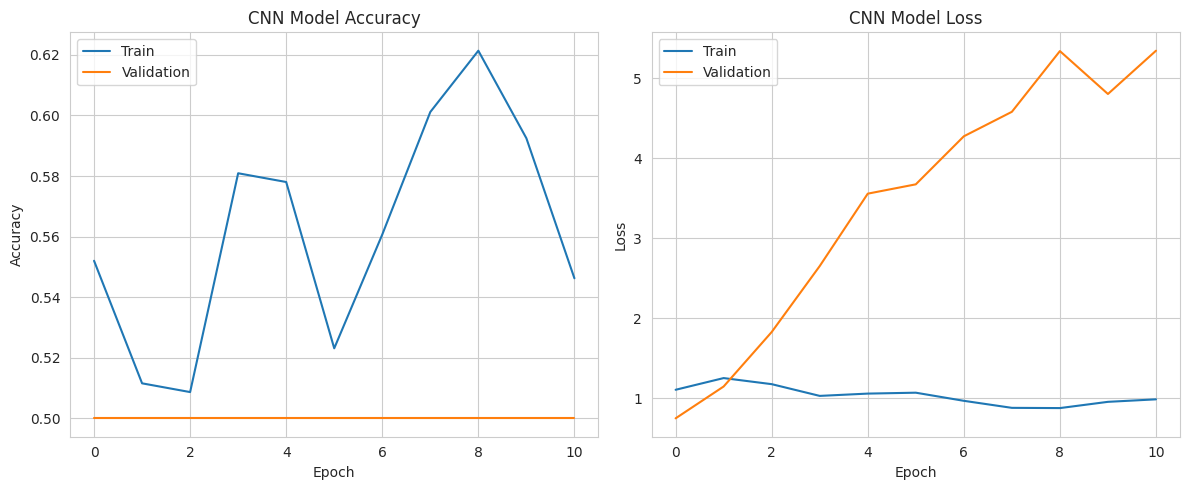

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
model_metrics = []

In [ ]:
cnn_metrics = evaluate_model(cnn_model, 'CNN', val_generator)
model_metrics.append(cnn_metrics)


Evaluating CNN...


#### **ResNet101**

In [ ]:
base_model_resnet = ResNet101(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze the layers of the base model so they are not updated during training
for layer in base_model_resnet.layers:
    layer.trainable = False

x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=x)

In [ ]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [ ]:
resnet_history = resnet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator,  callbacks=callbacks)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.4624 - f1_score: 0.4620 - loss: 0.8557 - precision: 0.4624 - recall: 0.4624 - val_accuracy: 0.5000 - val_f1_score: 0.3333 - val_loss: 0.7070 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 371ms/step - accuracy: 0.5173 - f1_score: 0.5164 - loss: 0.7689 - precision: 0.5173 - recall: 0.5173 - val_accuracy: 0.4651 - val_f1_score: 0.3515 - val_loss: 0.7070 - val_precision: 0.4651 - val_recall: 0.4651
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.5405 - f1_score: 0.5398 - loss: 0.7555 - precision: 0.5405 - recall: 0.5405 - val_accuracy: 0.4884 - val_f1_score: 0.3281 - val_loss: 0.7001 - val_precision: 0.4884 - val_recall: 0.4884
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.4827 - f1_score: 0.4753 - loss: 0.7841 - precision: 0.4827 - recall: 0.4827 - val_accuracy: 0.5000 - val_f1_score: 0.3706 - val_loss: 0.7148 - val_precision: 0.5000 - val_recall: 0

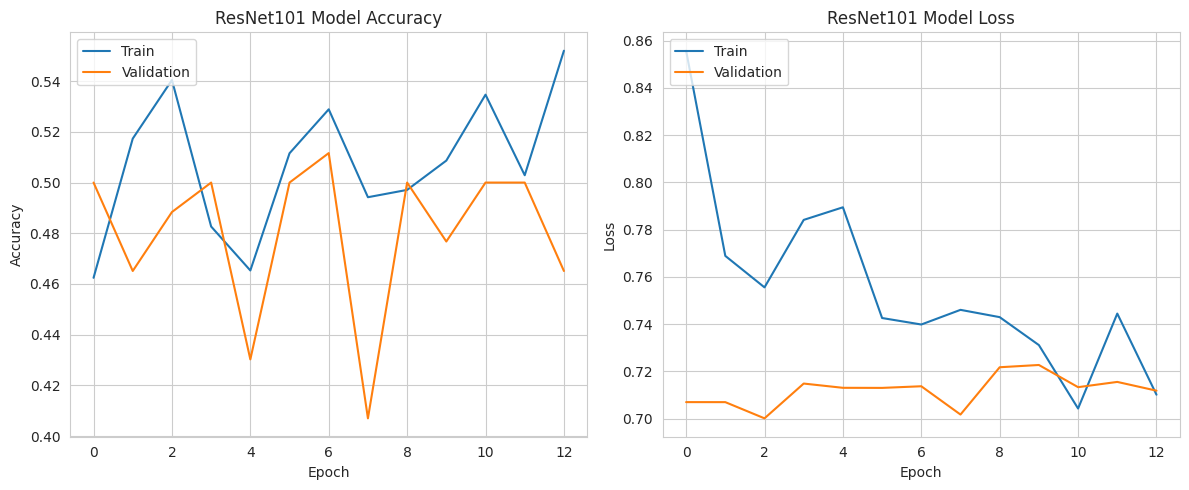

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'])
plt.plot(resnet_history.history['val_accuracy'])
plt.title('ResNet101 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'])
plt.plot(resnet_history.history['val_loss'])
plt.title('ResNet101 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
resnet_metrics = evaluate_model(resnet_model, 'ResNet101', val_generator)
model_metrics.append(resnet_metrics)


Evaluating ResNet101...


#### **DenseNet201**

In [ ]:
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(class_len, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=x)

In [ ]:
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [ ]:
densenet_history = densenet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, callbacks=callbacks)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.4798 - f1_score: 0.4797 - loss: 0.8816 - precision: 0.4798 - recall: 0.4798 - val_accuracy: 0.6744 - val_f1_score: 0.6716 - val_loss: 0.6229 - val_precision: 0.6744 - val_recall: 0.6744
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.6618 - f1_score: 0.6608 - loss: 0.6283 - precision: 0.6618 - recall: 0.6618 - val_accuracy: 0.7209 - val_f1_score: 0.7208 - val_loss: 0.5346 - val_precision: 0.7209 - val_recall: 0.7209
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step - accuracy: 0.7110 - f1_score: 0.7098 - loss: 0.5617 - precision: 0.7110 - recall: 0.7110 - val_accuracy: 0.6977 - val_f1_score: 0.6950 - val_loss: 0.5359 - val_precision: 0.6977 - val_recall: 0.6977
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step - accuracy: 0.7572 - f1_score: 0.7568 - loss: 0.5162 - precision: 0.7572 - recall: 0.7572 - val_accuracy: 0.7442 - val_f1_score: 0.7407 - val_loss: 0.5276 - val_precision: 0.7442 - val_recall: 

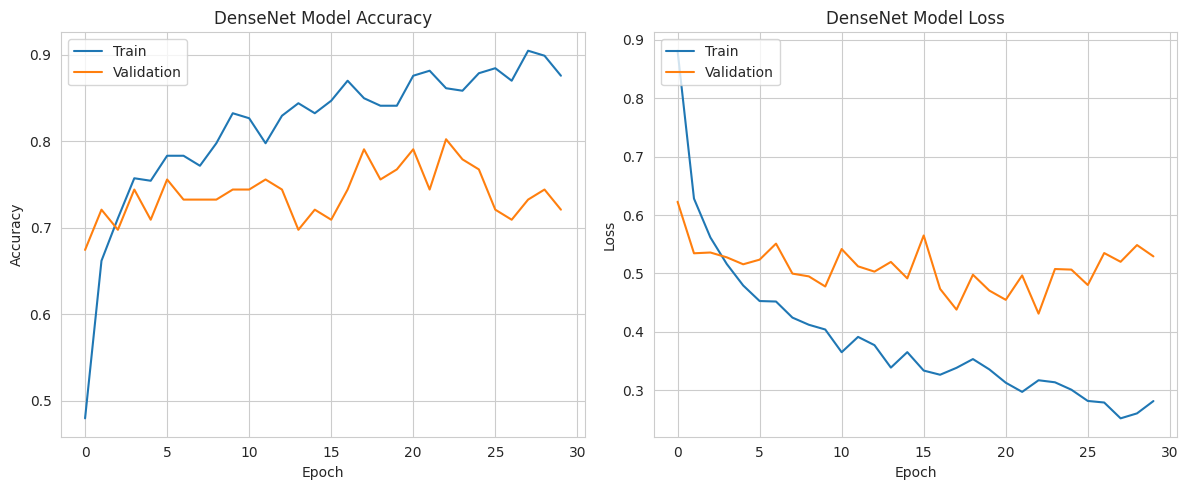

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(densenet_history.history['accuracy'])
plt.plot(densenet_history.history['val_accuracy'])
plt.title('DenseNet Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(densenet_history.history['loss'])
plt.plot(densenet_history.history['val_loss'])
plt.title('DenseNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
densenet_metrics = evaluate_model(densenet_model, 'DenseNet', val_generator)
model_metrics.append(densenet_metrics)


Evaluating DenseNet...


## **Metrics Plot**

In [ ]:
metrics_df = pd.DataFrame(model_metrics)
print("\nAll Model Evaluation Metrics:")
print(metrics_df)


All Model Evaluation Metrics:
       Model      Loss  Accuracy  Precision    Recall  F1-Score
0        CNN  0.746069  0.500000   0.500000  0.500000  0.333333
1  ResNet101  0.700621  0.511628   0.511628  0.511628  0.376812
2   DenseNet  0.454185  0.744186   0.744186  0.744186  0.744048


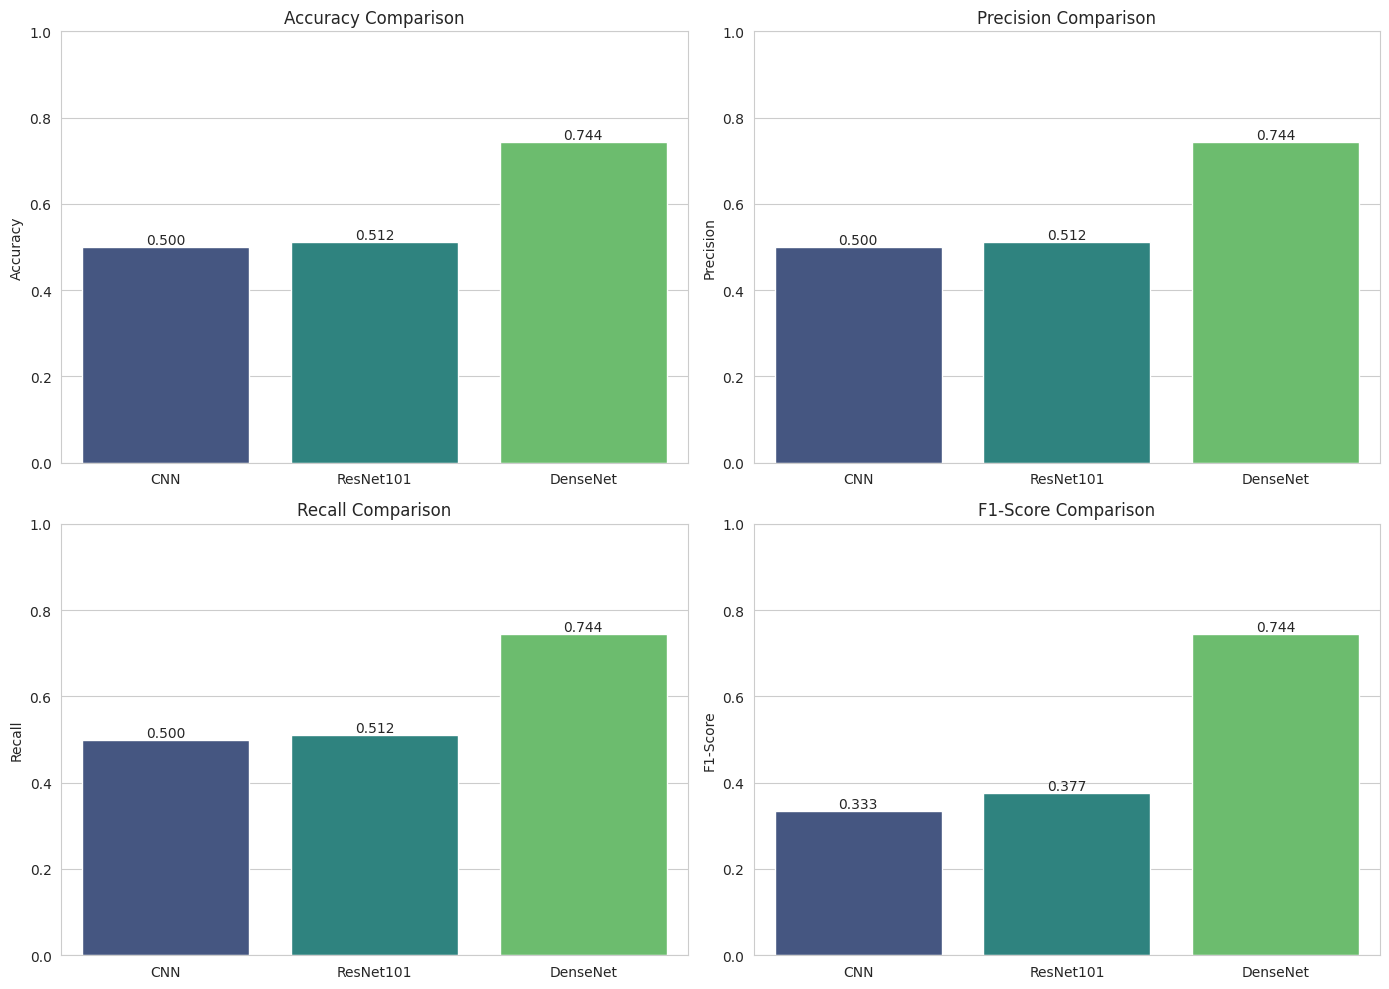

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten to iterate easily

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(
        x='Model',
        y=metric,
        data=metrics_df,
        ax=axes[i],
        palette='viridis'
    )

    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1)

    # Add value labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

Generating confusion matrix for CNN...
Generating confusion matrix for ResNet101...
Generating confusion matrix for DenseNet...


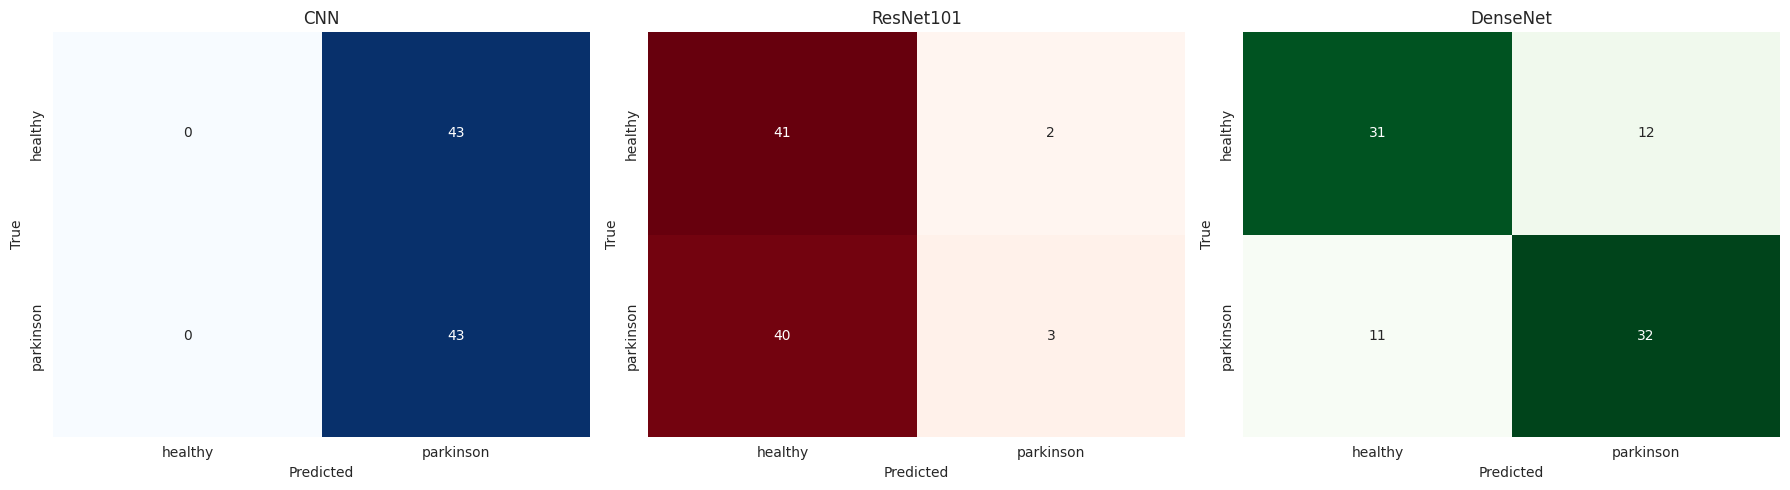

In [ ]:
from sklearn.metrics import confusion_matrix

class_names = list(train_generator.class_indices.keys())

models_to_evaluate = {
    'CNN': cnn_model,
    'ResNet101': resnet_model,
    'DenseNet': densenet_model
}

# Create 1 row × 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmaps = ['Blues', 'Reds', 'Greens']

for i, (model_name, model) in enumerate(models_to_evaluate.items()):
    print(f"Generating confusion matrix for {model_name}...")

    val_generator.reset()

    true_labels = val_generator.classes[val_generator.index_array]

    predictions = model.predict(val_generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_classes)

    # Plot
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmaps[i],
        cbar=False,
        ax=axes[i],
        xticklabels=class_names,
        yticklabels=class_names
    )

    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

## **Test Predictions**

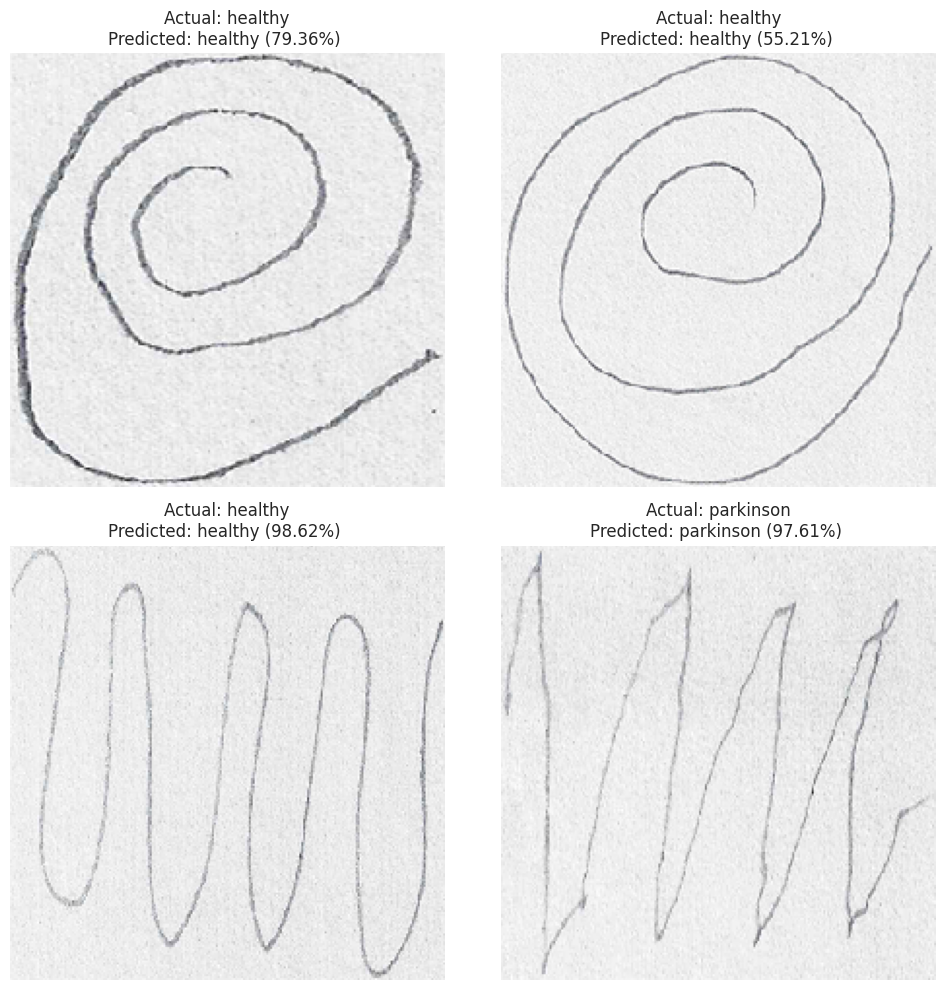

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input

class_names = list(train_generator.class_indices.keys())

test_image_paths = []
test_true_labels = []

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            test_image_paths.append(os.path.join(class_path, img_name))
            test_true_labels.append(class_names.index(class_folder))

num_samples = min(4, len(test_image_paths))
random_indices = random.sample(range(len(test_image_paths)), num_samples)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    img_path = test_image_paths[idx]
    true_label_idx = test_true_labels[idx]
    true_label = class_names[true_label_idx]

    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = densenet_model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_label = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_label} ({confidence:.2f}%) ")
    plt.axis('off')

plt.tight_layout()
plt.show()